In [ ]:
import numpy as np
import pandas as pd
from scipy.io import arff

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score


In [25]:
class BaggingClassifierCustom:
    def __init__(self, base_estimator="tree", n_estimators=10, knn_k=5, random_state=None):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.knn_k = knn_k
        self.random_state = random_state
        self.models = []

    def _create_model(self, seed):
        if self.base_estimator == "tree":
            return DecisionTreeClassifier(max_depth=1, random_state=seed)
        elif self.base_estimator == "knn":
            return KNeighborsClassifier(
                        n_neighbors=self.knn_k,
                        algorithm="brute",
                        n_jobs=1
                    )
        else:
            raise ValueError("base_estimator must be 'tree' or 'knn'")

    def fit(self, X, y):
        np.random.seed(self.random_state)
        self.models = []
        n_samples = X.shape[0]

        for i in range(self.n_estimators):
            # Bootstrap sampling
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_boot = X[indices]
            y_boot = y[indices]

            model = self._create_model(seed=i)
            model.fit(X_boot, y_boot)
            self.models.append(model)

    def predict(self, X):
        predictions = np.array([model.predict(X) for model in self.models])

        # Majority vote
        return np.apply_along_axis(
            lambda x: np.bincount(x).argmax(),
            axis=0,
            arr=predictions
        )


In [26]:
def cv_optimal_n_estimators(X, y, base_estimator, n_estimators_list, knn_k=5):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    mean_accuracies = []

    for n_estimators in n_estimators_list:
        fold_accuracies = []

        for train_idx, val_idx in skf.split(X, y):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model = BaggingClassifierCustom(
                base_estimator=base_estimator,
                n_estimators=n_estimators,
                random_state=42
            )

            model.fit(X_train, y_train)
            print(X_val.shape)
            y_pred = model.predict(X_val)

            fold_accuracies.append(accuracy_score(y_val, y_pred))

        mean_accuracies.append(np.mean(fold_accuracies))

    best_index = np.argmax(mean_accuracies)
    return n_estimators_list[best_index], mean_accuracies


In [27]:
# Load the ARFF file
data, meta = arff.loadarff("WDBC.arff.txt")

# Convert to pandas DataFrame
df = pd.DataFrame(data)

# Convert Class column from bytes to integer if needed
if df['Class'].dtype == object:
    df['Class'] = df['Class'].str.decode('utf-8').astype(int)

# Convert to numpy arrays
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

# Candidate numbers of classifiers
n_estimators_list = [1, 5, 10, 20, 30, 50]

# # ----- Decision Tree (stumps) -----
# best_n_tree, tree_scores = cv_optimal_n_estimators(
#     X, y,
#     base_estimator="tree",
#     n_estimators_list=n_estimators_list
# )

# print("Decision Tree Bagging")
# for n, acc in zip(n_estimators_list, tree_scores):
#     print(f"n_estimators={n:2d} | CV accuracy={acc:.4f}")

# print(f"Optimal number of classifiers (Tree): {best_n_tree}")
# print()

# ----- kNN -----
best_n_knn, knn_scores = cv_optimal_n_estimators(
    X, y,
    base_estimator="knn",
    n_estimators_list=n_estimators_list,
    knn_k=5
)

print("kNN Bagging")
for n, acc in zip(n_estimators_list, knn_scores):
    print(f"n_estimators={n:2d} | CV accuracy={acc:.4f}")

print(f"Optimal number of classifiers (kNN): {best_n_knn}")


Features shape: (569, 30)
Labels shape: (569,)
(114, 30)


AttributeError: 'NoneType' object has no attribute 'split'

In [5]:
from scipy.io import arff
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the ARFF file
data, meta = arff.loadarff("WDBC.arff.txt")

# Convert to pandas DataFrame
df = pd.DataFrame(data)

# Convert Class column from bytes to integer if needed
if df['Class'].dtype == object:
    df['Class'] = df['Class'].str.decode('utf-8').astype(int)

# Convert to numpy arrays
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -------------------------------
# Bagging implementation
# -------------------------------

def bagging_classifier(X_train, y_train, X_test, n_estimators):
    """
    Implements Bagging with decision trees of depth 1.
    
    Parameters:
        X_train, y_train : training data
        X_test           : test data
        n_estimators     : number of base classifiers
    
    Returns:
        y_pred : final predictions on X_test
    """
    n_samples = X_train.shape[0]
    all_predictions = []

    for i in range(n_estimators):
        # Bootstrap sampling
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        X_bootstrap = X_train[indices]
        y_bootstrap = y_train[indices]

        # Train weak learner (decision stump)
        clf = DecisionTreeClassifier(max_depth=1, random_state=i)
        clf.fit(X_bootstrap, y_bootstrap)

        # Predict on test set
        preds = clf.predict(X_test)
        all_predictions.append(preds)

    # Convert to array: shape (n_estimators, n_test_samples)
    all_predictions = np.array(all_predictions)

    # Majority vote
    y_pred = np.apply_along_axis(
        lambda x: np.bincount(x).argmax(),
        axis=0,
        arr=all_predictions
    )

    return y_pred

# Run Bagging
n_estimators = 50
y_pred = bagging_classifier(X_train, y_train, X_test, n_estimators)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Bagging Accuracy with {n_estimators} classifiers: {accuracy:.4f}")


Features shape: (569, 30)
Labels shape: (569,)
Bagging Accuracy with 50 classifiers: 0.9006


Features shape: (569, 30)
Labels shape: (569,)
Unique classes: [1 2]

FINDING OPTIMAL N_ESTIMATORS FOR DECISION TREE

=== Cross-Validation for TREE ===
Testing n_estimators: [1, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200]
n_estimators=1: Mean accuracy=0.9087 (+/-0.0187)
n_estimators=5: Mean accuracy=0.9174 (+/-0.0238)
n_estimators=10: Mean accuracy=0.9174 (+/-0.0204)
n_estimators=20: Mean accuracy=0.9209 (+/-0.0199)
n_estimators=30: Mean accuracy=0.9192 (+/-0.0224)
n_estimators=40: Mean accuracy=0.9174 (+/-0.0251)
n_estimators=50: Mean accuracy=0.9227 (+/-0.0224)
n_estimators=75: Mean accuracy=0.9174 (+/-0.0263)
n_estimators=100: Mean accuracy=0.9174 (+/-0.0263)
n_estimators=150: Mean accuracy=0.9227 (+/-0.0217)
n_estimators=200: Mean accuracy=0.9175 (+/-0.0280)

Optimal n_estimators: 150 with accuracy: 0.9227


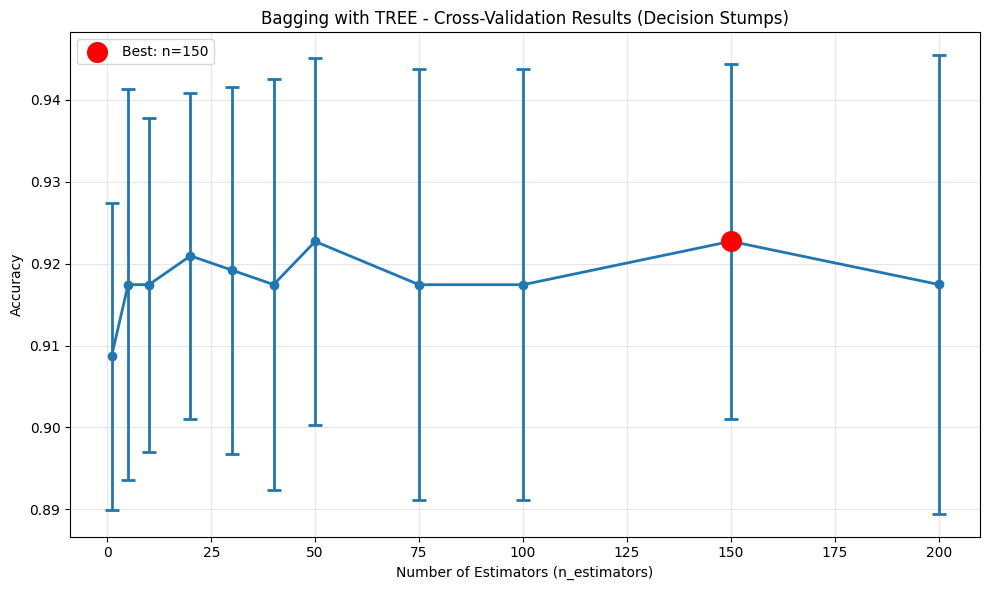


FINDING OPTIMAL N_ESTIMATORS FOR KNN

=== Cross-Validation for KNN ===
Testing n_estimators: [1, 5, 10, 20, 30, 40, 50]


AttributeError: 'NoneType' object has no attribute 'split'

In [16]:
from scipy.io import arff
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils import resample
import matplotlib.pyplot as plt

class BaggingClassifier:
    """
    Bagging ensemble classifier that can use either DecisionTreeClassifier or KNeighborsClassifier.
    """
    
    def __init__(self, base_estimator='tree', n_estimators=10, random_state=None, **kwargs):
        """
        Initialize the Bagging classifier.
        
        Parameters:
        -----------
        base_estimator : str, default='tree'
            Type of base estimator to use. Options: 'tree' or 'knn'.
        n_estimators : int, default=10
            Number of base estimators in the ensemble.
        random_state : int, default=None
            Random seed for reproducibility.
        **kwargs : dict
            Additional parameters for the base estimator.
            For 'tree': max_depth, criterion, etc.
            For 'knn': n_neighbors, weights, etc.
        """
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.estimator_params = kwargs
        self.estimators_ = []
        self.estimator_data_ = []  # Store training data for each estimator
        self.oob_indices_ = []
        
    def _create_base_estimator(self, estimator_id=0):
        """Create a single base estimator with unique random state."""
        if self.base_estimator == 'tree':
            # Create decision tree with depth 1 by default
            params = {'max_depth': 1, 'random_state': None}
            params.update(self.estimator_params)
            if self.random_state is not None:
                params['random_state'] = self.random_state + estimator_id
            return DecisionTreeClassifier(**params)
        
        elif self.base_estimator == 'knn':
            # Create KNN classifier
            params = {'n_neighbors': 5}  # Default value
            params.update(self.estimator_params)
            return KNeighborsClassifier(**params)
        
        else:
            raise ValueError(f"Unknown base estimator: {self.base_estimator}. Use 'tree' or 'knn'.")
    
    def fit(self, X, y):
        """
        Train the Bagging classifier.
        
        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Training data.
        y : array-like of shape (n_samples,)
            Target values.
        """
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        self.estimators_ = []
        self.estimator_data_ = []
        self.oob_indices_ = []
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        
        for i in range(self.n_estimators):
            # Create bootstrap sample (with replacement)
            bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)
            oob_indices = np.setdiff1d(np.arange(n_samples), np.unique(bootstrap_indices))
            
            X_bootstrap = X[bootstrap_indices]
            y_bootstrap = y[bootstrap_indices]
            
            # Create and train base estimator
            estimator = self._create_base_estimator(i)
            
            # Store training data for KNN
            if self.base_estimator == 'knn':
                # For KNN, we need to fit and store the bootstrap data
                estimator.fit(X_bootstrap, y_bootstrap)
                # Store the bootstrap data for this estimator
                self.estimator_data_.append((X_bootstrap, y_bootstrap))
            else:
                estimator.fit(X_bootstrap, y_bootstrap)
                self.estimator_data_.append(None)  # Placeholder for trees
            
            self.estimators_.append(estimator)
            self.oob_indices_.append(oob_indices)
        
        return self
    
    def _predict_single_estimator(self, estimator, estimator_idx, X):
        """Predict using a single estimator."""
        if self.base_estimator == 'knn':
            # For KNN, use the stored estimator directly
            # KNN estimators are already fitted
            return estimator.predict(X)
        else:
            # For tree, predict directly
            return estimator.predict(X)
    
    def predict(self, X):
        """
        Predict class labels for samples in X.
        
        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Test data.
            
        Returns:
        --------
        y_pred : array of shape (n_samples,)
            Predicted class labels.
        """
        # Collect predictions from all estimators
        all_predictions = []
        for i, estimator in enumerate(self.estimators_):
            pred = self._predict_single_estimator(estimator, i, X)
            all_predictions.append(pred)
        
        all_predictions = np.array(all_predictions)
        
        # Majority vote
        n_samples = X.shape[0]
        y_pred = np.zeros(n_samples, dtype=int)
        
        for i in range(n_samples):
            votes = all_predictions[:, i]
            # Find the most common class (mode)
            unique_classes, counts = np.unique(votes, return_counts=True)
            y_pred[i] = unique_classes[np.argmax(counts)]
        
        return y_pred
    
    def predict_proba(self, X):
        """
        Predict class probabilities for samples in X.
        
        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Test data.
            
        Returns:
        --------
        proba : array of shape (n_samples, n_classes)
            Class probabilities.
        """
        # Collect predictions from all estimators
        all_predictions = []
        for i, estimator in enumerate(self.estimators_):
            pred = self._predict_single_estimator(estimator, i, X)
            all_predictions.append(pred)
        
        all_predictions = np.array(all_predictions)
        n_samples = X.shape[0]
        
        # Initialize probability array
        proba = np.zeros((n_samples, self.n_classes_))
        
        # Create mapping from class label to index
        class_to_idx = {cls: idx for idx, cls in enumerate(self.classes_)}
        
        for i in range(n_samples):
            votes = all_predictions[:, i]
            for cls in votes:
                proba[i, class_to_idx[cls]] += 1
            # Normalize
            proba[i] /= self.n_estimators
        
        return proba
    
    def oob_score(self, y):
        """
        Compute out-of-bag score.
        
        Parameters:
        -----------
        y : array-like of shape (n_samples,)
            True target values.
            
        Returns:
        --------
        score : float
            Out-of-bag accuracy score.
        """
        n_samples = len(y)
        predictions = np.zeros((n_samples, self.n_classes_))
        vote_counts = np.zeros((n_samples,))
        
        # Create mapping from class label to index
        class_to_idx = {cls: idx for idx, cls in enumerate(self.classes_)}
        
        # For each estimator, predict on its OOB samples
        for i, (estimator, oob_idx) in enumerate(zip(self.estimators_, self.oob_indices_)):
            if len(oob_idx) > 0:
                # Get X_oob from the original training data
                X_oob = self.estimator_data_[i][0] if self.base_estimator == 'knn' else None
                # Actually, we need to store the original X during fitting
                # Let's modify our approach
                if hasattr(self, 'X_original_'):
                    X_oob = self.X_original_[oob_idx]
                    y_pred_oob = self._predict_single_estimator(estimator, i, X_oob)
                    
                    # Accumulate votes
                    for j, idx in enumerate(oob_idx):
                        class_idx = class_to_idx[y_pred_oob[j]]
                        predictions[idx, class_idx] += 1
                        vote_counts[idx] += 1
        
        # Only consider samples that were OOB for at least one estimator
        valid_indices = vote_counts > 0
        if np.sum(valid_indices) == 0:
            return 0.0
        
        # Get final predictions (class with most votes)
        final_predictions_idx = np.argmax(predictions[valid_indices], axis=1)
        final_predictions = self.classes_[final_predictions_idx]
        
        # Calculate accuracy
        accuracy = np.mean(final_predictions == y[valid_indices])
        return accuracy


def find_optimal_n_estimators(X, y, base_estimator='tree', n_estimators_list=None, 
                              n_splits=5, random_state=42, **kwargs):
    """
    Find optimal number of estimators using stratified 5-fold cross-validation.
    
    Parameters:
    -----------
    X : array-like, feature matrix
    y : array-like, target vector
    base_estimator : str, 'tree' or 'knn'
    n_estimators_list : list, list of n_estimators to try
    n_splits : int, number of CV folds
    random_state : int, random seed
    **kwargs : additional parameters for base estimator
    
    Returns:
    --------
    best_n_estimators : int, optimal number of estimators
    cv_results : dict, cross-validation results
    """
    if n_estimators_list is None:
        n_estimators_list = [1, 5, 10, 20, 30, 40, 50, 75, 100]
    
    # Initialize stratified k-fold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    # Store results
    cv_results = {
        'n_estimators': n_estimators_list,
        'mean_scores': [],
        'std_scores': [],
        'fold_scores': {n: [] for n in n_estimators_list}
    }
    
    print(f"\n=== Cross-Validation for {base_estimator.upper()} ===")
    print(f"Testing n_estimators: {n_estimators_list}")
    
    # Perform cross-validation for each n_estimators
    for n_estimators in n_estimators_list:
        fold_scores = []
        
        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y)):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            # Create and train bagging classifier
            bagging = BaggingClassifier(
                base_estimator=base_estimator,
                n_estimators=n_estimators,
                random_state=random_state + fold_idx,
                **kwargs
            )
            bagging.fit(X_train, y_train)
            
            # Predict on validation set
            y_pred = bagging.predict(X_val)
            
            # Calculate accuracy
            accuracy = accuracy_score(y_val, y_pred)
            fold_scores.append(accuracy)
            
            cv_results['fold_scores'][n_estimators].append(accuracy)
        
        # Calculate mean and std for this n_estimators
        mean_score = np.mean(fold_scores)
        std_score = np.std(fold_scores)
        cv_results['mean_scores'].append(mean_score)
        cv_results['std_scores'].append(std_score)
        
        print(f"n_estimators={n_estimators}: Mean accuracy={mean_score:.4f} (+/-{std_score:.4f})")
    
    # Find best n_estimators
    best_idx = np.argmax(cv_results['mean_scores'])
    best_n_estimators = n_estimators_list[best_idx]
    best_score = cv_results['mean_scores'][best_idx]
    
    print(f"\nOptimal n_estimators: {best_n_estimators} with accuracy: {best_score:.4f}")
    
    return best_n_estimators, cv_results


def plot_cv_results(cv_results, base_estimator, title_suffix=""):
    """Plot cross-validation results."""
    plt.figure(figsize=(10, 6))
    n_estimators = cv_results['n_estimators']
    mean_scores = cv_results['mean_scores']
    std_scores = cv_results['std_scores']
    
    plt.errorbar(n_estimators, mean_scores, yerr=std_scores, 
                 fmt='-o', capsize=5, capthick=2, linewidth=2)
    plt.xlabel('Number of Estimators (n_estimators)')
    plt.ylabel('Accuracy')
    plt.title(f'Bagging with {base_estimator.upper()} - Cross-Validation Results {title_suffix}')
    plt.grid(True, alpha=0.3)
    
    # Highlight the best point
    best_idx = np.argmax(mean_scores)
    plt.scatter(n_estimators[best_idx], mean_scores[best_idx], 
                color='red', s=200, zorder=5, label=f'Best: n={n_estimators[best_idx]}')
    plt.legend()
    plt.tight_layout()
    plt.show()


# Main execution
if __name__ == "__main__":
    # Load the ARFF file
    data, meta = arff.loadarff("WDBC.arff.txt")
    
    # Convert to pandas DataFrame (easier to work with)
    df = pd.DataFrame(data)
    
    # Convert Class column from bytes to integer if needed
    if df['Class'].dtype == object:
        df['Class'] = df['Class'].str.decode('utf-8').astype(int)
    
    # Convert to numpy arrays
    X = df.iloc[:, :-1].values  # All columns except last
    y = df.iloc[:, -1].values   # Last column (Class)
    
    print(f"Features shape: {X.shape}")
    print(f"Labels shape: {y.shape}")
    print(f"Unique classes: {np.unique(y)}")
    
    # Standardize features for KNN (important for distance-based methods)
    from sklearn.preprocessing import StandardScaler
    
    X_original = X.copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Define parameters for different base estimators
    tree_params = {'max_depth': 1}  # Decision stumps
    knn_params = {'n_neighbors': 5, 'weights': 'uniform'}
    
    # List of n_estimators to test
    n_estimators_list = [1, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200]
    
    # Find optimal n_estimators for Decision Tree (use original data)
    print("\n" + "="*60)
    print("FINDING OPTIMAL N_ESTIMATORS FOR DECISION TREE")
    print("="*60)
    best_n_tree, cv_tree = find_optimal_n_estimators(
        X_original, y, 
        base_estimator='tree',
        n_estimators_list=n_estimators_list,
        random_state=42,
        **tree_params
    )
    
    # Plot results for Decision Tree
    plot_cv_results(cv_tree, 'tree', "(Decision Stumps)")
    
    # Find optimal n_estimators for KNN (use scaled data)
    print("\n" + "="*60)
    print("FINDING OPTIMAL N_ESTIMATORS FOR KNN")
    print("="*60)
    best_n_knn, cv_knn = find_optimal_n_estimators(
        X_scaled, y, 
        base_estimator='knn',
        n_estimators_list=[1, 5, 10, 20, 30, 40, 50],  # Smaller list for speed
        random_state=42,
        **knn_params
    )
    
    # Plot results for KNN
    plot_cv_results(cv_knn, 'knn', f"(KNN with n_neighbors={knn_params['n_neighbors']})")
    
    # Compare the two approaches with their optimal n_estimators
    print("\n" + "="*60)
    print("FINAL COMPARISON WITH OPTIMAL N_ESTIMATORS")
    print("="*60)
    
    # Final evaluation with optimal parameters
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    final_scores_tree = []
    final_scores_knn = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_original, y)):
        X_train_orig, X_test_orig = X_original[train_idx], X_original[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Scale the data for KNN
        scaler_fold = StandardScaler()
        X_train_scaled = scaler_fold.fit_transform(X_train_orig)
        X_test_scaled = scaler_fold.transform(X_test_orig)
        
        # Train with Decision Tree (original data)
        bagging_tree = BaggingClassifier(
            base_estimator='tree',
            n_estimators=best_n_tree,
            random_state=42 + fold_idx,
            **tree_params
        )
        bagging_tree.fit(X_train_orig, y_train)
        y_pred_tree = bagging_tree.predict(X_test_orig)
        score_tree = accuracy_score(y_test, y_pred_tree)
        final_scores_tree.append(score_tree)
        
        # Train with KNN (scaled data)
        bagging_knn = BaggingClassifier(
            base_estimator='knn',
            n_estimators=best_n_knn,
            random_state=42 + fold_idx,
            **knn_params
        )
        bagging_knn.fit(X_train_scaled, y_train)
        y_pred_knn = bagging_knn.predict(X_test_scaled)
        score_knn = accuracy_score(y_test, y_pred_knn)
        final_scores_knn.append(score_knn)
    
    print(f"\nDecision Tree (n_estimators={best_n_tree}):")
    print(f"  Mean accuracy: {np.mean(final_scores_tree):.4f} (+/-{np.std(final_scores_tree):.4f})")
    print(f"  Fold accuracies: {[f'{s:.4f}' for s in final_scores_tree]}")
    
    print(f"\nKNN (n_estimators={best_n_knn}, n_neighbors={knn_params['n_neighbors']}):")
    print(f"  Mean accuracy: {np.mean(final_scores_knn):.4f} (+/-{np.std(final_scores_knn):.4f})")
    print(f"  Fold accuracies: {[f'{s:.4f}' for s in final_scores_knn]}")
    
    # Compare which is better
    mean_tree = np.mean(final_scores_tree)
    mean_knn = np.mean(final_scores_knn)
    
    if mean_tree > mean_knn:
        print(f"\n✓ Decision Tree performs better by {mean_tree - mean_knn:.4f}")
        print(f"  Optimal configuration: n_estimators={best_n_tree}")
    elif mean_knn > mean_tree:
        print(f"\n✓ KNN performs better by {mean_knn - mean_tree:.4f}")
        print(f"  Optimal configuration: n_estimators={best_n_knn}")
    else:
        print("\n✓ Both methods perform equally well")
    
    # Additional analysis: Feature importance for trees
    if best_n_tree > 0:
        print("\n" + "="*60)
        print("FEATURE IMPORTANCE ANALYSIS (Decision Tree)")
        print("="*60)
        
        # Train on full dataset
        bagging_tree_full = BaggingClassifier(
            base_estimator='tree',
            n_estimators=best_n_tree,
            random_state=42,
            **tree_params
        )
        bagging_tree_full.fit(X_original, y)
        
        # Calculate feature importance based on splits
        feature_importances = np.zeros(X_original.shape[1])
        
        for tree in bagging_tree_full.estimators_:
            # Check if tree has splits
            if hasattr(tree, 'tree_') and tree.tree_.feature[0] >= 0:
                feature_importances[tree.tree_.feature[0]] += 1
        
        # Normalize
        feature_importances = feature_importances / len(bagging_tree_full.estimators_)
        
        # Print top 10 most important features
        top_indices = np.argsort(feature_importances)[-10:][::-1]
        print("\nTop 10 most frequently used features for splitting:")
        for idx in top_indices:
            if feature_importances[idx] > 0:
                print(f"  Feature V{idx+1}: {feature_importances[idx]:.3f}")

Features shape: (569, 30)
Labels shape: (569,)
Unique classes: [1 2]

FINDING OPTIMAL N_ESTIMATORS FOR DECISION TREE

=== Cross-Validation for TREE ===
Testing n_estimators: [1, 5, 10, 20, 30, 40, 50, 75, 100]
n_estimators=1: Mean accuracy=0.9087 (+/-0.0187)
n_estimators=5: Mean accuracy=0.9174 (+/-0.0238)
n_estimators=10: Mean accuracy=0.9174 (+/-0.0204)
n_estimators=20: Mean accuracy=0.9209 (+/-0.0199)
n_estimators=30: Mean accuracy=0.9192 (+/-0.0224)
n_estimators=40: Mean accuracy=0.9174 (+/-0.0251)
n_estimators=50: Mean accuracy=0.9227 (+/-0.0224)
n_estimators=75: Mean accuracy=0.9174 (+/-0.0263)
n_estimators=100: Mean accuracy=0.9174 (+/-0.0263)

Optimal n_estimators: 50 with accuracy: 0.9227


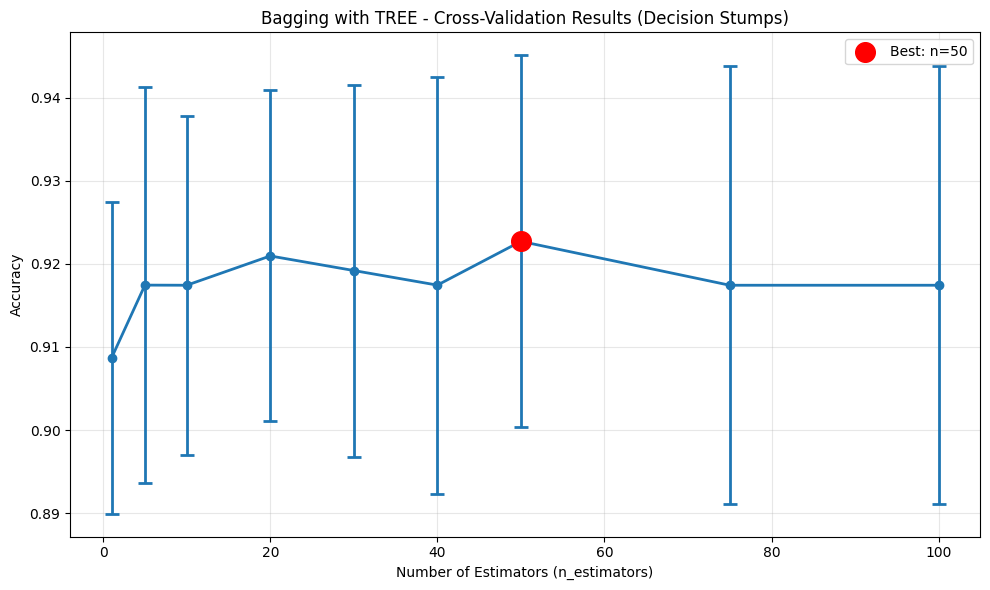


FINDING OPTIMAL N_ESTIMATORS FOR KNN

=== Cross-Validation for KNN ===
Testing n_estimators: [1, 5, 10, 15, 20, 25, 30]
n_estimators=1: Mean accuracy=0.9490 (+/-0.0151)
n_estimators=5: Mean accuracy=0.9649 (+/-0.0260)
n_estimators=10: Mean accuracy=0.9649 (+/-0.0200)
n_estimators=15: Mean accuracy=0.9649 (+/-0.0157)
n_estimators=20: Mean accuracy=0.9631 (+/-0.0161)
n_estimators=25: Mean accuracy=0.9631 (+/-0.0161)
n_estimators=30: Mean accuracy=0.9631 (+/-0.0161)

Optimal n_estimators: 5 with accuracy: 0.9649


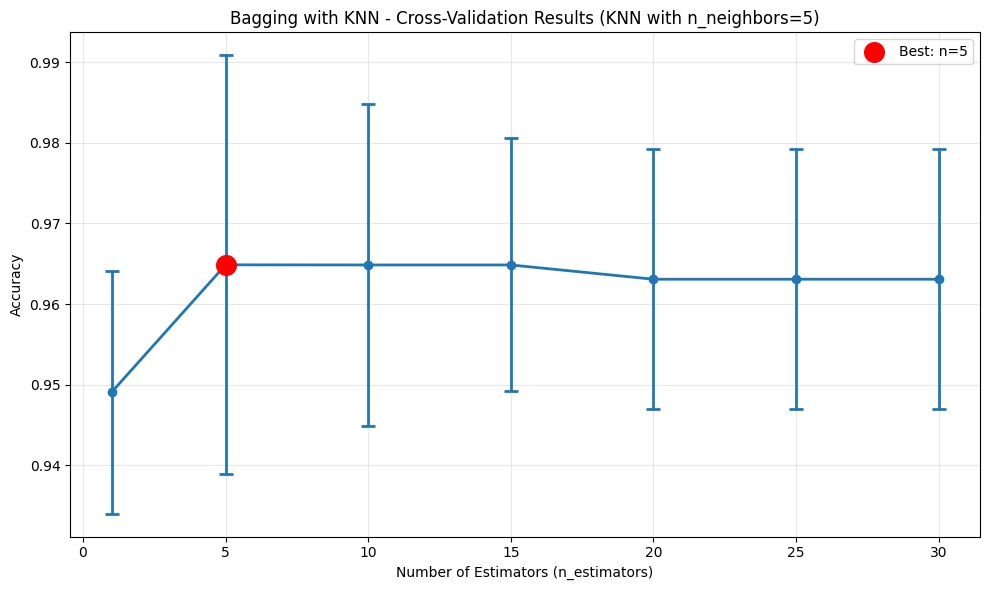


FINAL COMPARISON WITH OPTIMAL N_ESTIMATORS

Decision Tree (n_estimators=50):
  Mean CV accuracy: 0.9227 (+/-0.0224)
  Mean OOB accuracy: 0.9143
  Fold accuracies: ['0.9561', '0.8947', '0.9035', '0.9211', '0.9381']

KNN (n_estimators=5, n_neighbors=5):
  Mean CV accuracy: 0.9614 (+/-0.0233)
  Mean OOB accuracy: 0.9611
  Fold accuracies: ['0.9912', '0.9298', '0.9386', '0.9737', '0.9735']

✓ KNN performs better by 0.0387
  Optimal configuration: n_estimators=5

FEATURE IMPORTANCE ANALYSIS (Decision Tree)

Top 10 most frequently used features for splitting:
  Feature V23: 0.340
  Feature V28: 0.300
  Feature V24: 0.160
  Feature V8: 0.140
  Feature V21: 0.060

SINGLE ESTIMATOR vs BAGGING COMPARISON

Single Decision Tree (depth=1):
  Mean accuracy: 0.8876 (+/-0.0283)
  Bagging improvement: 0.0351

Single KNN (k=5):
  Mean accuracy: 0.9631 (+/-0.0179)
  Bagging improvement: -0.0017


In [29]:
from scipy.io import arff
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

class SimpleKNN:
    """
    A simplified KNN implementation to avoid threading issues.
    """
    def __init__(self, n_neighbors=5, weights='uniform'):
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.X_train = None
        self.y_train = None
        
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self
    
    def predict(self, X):
        n_samples = X.shape[0]
        predictions = np.zeros(n_samples, dtype=self.y_train.dtype)
        
        for i in range(n_samples):
            # Calculate distances
            distances = np.sqrt(np.sum((self.X_train - X[i])**2, axis=1))
            
            # Get k nearest neighbors
            nearest_indices = np.argsort(distances)[:self.n_neighbors]
            nearest_labels = self.y_train[nearest_indices]
            
            # Majority vote
            if self.weights == 'uniform':
                predictions[i] = Counter(nearest_labels).most_common(1)[0][0]
            else:
                # Distance-weighted voting
                nearest_distances = distances[nearest_indices]
                weights = 1.0 / (nearest_distances + 1e-10)  # Avoid division by zero
                weighted_votes = {}
                for label, weight in zip(nearest_labels, weights):
                    weighted_votes[label] = weighted_votes.get(label, 0) + weight
                predictions[i] = max(weighted_votes.items(), key=lambda x: x[1])[0]
        
        return predictions

class BaggingClassifier:
    """
    Bagging ensemble classifier that can use either DecisionTreeClassifier or SimpleKNN.
    """
    
    def __init__(self, base_estimator='tree', n_estimators=10, random_state=None, **kwargs):
        """
        Initialize the Bagging classifier.
        
        Parameters:
        -----------
        base_estimator : str, default='tree'
            Type of base estimator to use. Options: 'tree' or 'knn'.
        n_estimators : int, default=10
            Number of base estimators in the ensemble.
        random_state : int, default=None
            Random seed for reproducibility.
        **kwargs : dict
            Additional parameters for the base estimator.
            For 'tree': max_depth, criterion, etc.
            For 'knn': n_neighbors, weights, etc.
        """
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.estimator_params = kwargs
        self.estimators_ = []
        self.estimator_data_ = []  # Store training data for each estimator
        self.oob_indices_ = []
        
    def _create_base_estimator(self, estimator_id=0):
        """Create a single base estimator."""
        if self.base_estimator == 'tree':
            # Create decision tree with depth 1 by default
            params = {'max_depth': 1, 'random_state': None}
            params.update(self.estimator_params)
            if self.random_state is not None:
                params['random_state'] = self.random_state + estimator_id
            return DecisionTreeClassifier(**params)
        
        elif self.base_estimator == 'knn':
            # Create simplified KNN classifier
            params = {'n_neighbors': 5}  # Default value
            params.update(self.estimator_params)
            return SimpleKNN(**params)
        
        else:
            raise ValueError(f"Unknown base estimator: {self.base_estimator}. Use 'tree' or 'knn'.")
    
    def fit(self, X, y):
        """
        Train the Bagging classifier.
        
        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Training data.
        y : array-like of shape (n_samples,)
            Target values.
        """
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        n_samples = X.shape[0]
        self.estimators_ = []
        self.estimator_data_ = []
        self.oob_indices_ = []
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        self.X_original_ = X  # Store original X for OOB
        self.y_original_ = y  # Store original y for OOB
        
        for i in range(self.n_estimators):
            # Create bootstrap sample (with replacement)
            bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)
            oob_indices = np.setdiff1d(np.arange(n_samples), np.unique(bootstrap_indices))
            
            X_bootstrap = X[bootstrap_indices]
            y_bootstrap = y[bootstrap_indices]
            
            # Create and train base estimator
            estimator = self._create_base_estimator(i)
            estimator.fit(X_bootstrap, y_bootstrap)
            
            # Store the bootstrap data for KNN (trees don't need it after fitting)
            if self.base_estimator == 'knn':
                self.estimator_data_.append((X_bootstrap, y_bootstrap))
            else:
                self.estimator_data_.append(None)
            
            self.estimators_.append(estimator)
            self.oob_indices_.append(oob_indices)
        
        return self
    
    def _predict_single_estimator(self, estimator, estimator_idx, X):
        """Predict using a single estimator."""
        return estimator.predict(X)
    
    def predict(self, X):
        """
        Predict class labels for samples in X.
        
        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Test data.
            
        Returns:
        --------
        y_pred : array of shape (n_samples,)
            Predicted class labels.
        """
        # Collect predictions from all estimators
        all_predictions = []
        for i, estimator in enumerate(self.estimators_):
            pred = self._predict_single_estimator(estimator, i, X)
            all_predictions.append(pred)
        
        all_predictions = np.array(all_predictions)
        
        # Majority vote
        n_samples = X.shape[0]
        y_pred = np.zeros(n_samples, dtype=int)
        
        for i in range(n_samples):
            votes = all_predictions[:, i]
            # Find the most common class (mode)
            unique_classes, counts = np.unique(votes, return_counts=True)
            y_pred[i] = unique_classes[np.argmax(counts)]
        
        return y_pred
    
    def predict_proba(self, X):
        """
        Predict class probabilities for samples in X.
        
        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Test data.
            
        Returns:
        --------
        proba : array of shape (n_samples, n_classes)
            Class probabilities.
        """
        # Collect predictions from all estimators
        all_predictions = []
        for i, estimator in enumerate(self.estimators_):
            pred = self._predict_single_estimator(estimator, i, X)
            all_predictions.append(pred)
        
        all_predictions = np.array(all_predictions)
        n_samples = X.shape[0]
        
        # Initialize probability array
        proba = np.zeros((n_samples, self.n_classes_))
        
        # Create mapping from class label to index
        class_to_idx = {cls: idx for idx, cls in enumerate(self.classes_)}
        
        for i in range(n_samples):
            votes = all_predictions[:, i]
            for cls in votes:
                proba[i, class_to_idx[cls]] += 1
            # Normalize
            proba[i] /= self.n_estimators
        
        return proba
    
    def oob_score(self):
        """
        Compute out-of-bag score.
        
        Returns:
        --------
        score : float
            Out-of-bag accuracy score.
        """
        n_samples = len(self.y_original_)
        predictions = np.zeros((n_samples, self.n_classes_))
        vote_counts = np.zeros((n_samples,))
        
        # Create mapping from class label to index
        class_to_idx = {cls: idx for idx, cls in enumerate(self.classes_)}
        
        # For each estimator, predict on its OOB samples
        for i, (estimator, oob_idx) in enumerate(zip(self.estimators_, self.oob_indices_)):
            if len(oob_idx) > 0:
                X_oob = self.X_original_[oob_idx]
                y_pred_oob = self._predict_single_estimator(estimator, i, X_oob)
                
                # Accumulate votes
                for j, idx in enumerate(oob_idx):
                    class_idx = class_to_idx[y_pred_oob[j]]
                    predictions[idx, class_idx] += 1
                    vote_counts[idx] += 1
        
        # Only consider samples that were OOB for at least one estimator
        valid_indices = vote_counts > 0
        if np.sum(valid_indices) == 0:
            return 0.0
        
        # Get final predictions (class with most votes)
        final_predictions_idx = np.argmax(predictions[valid_indices], axis=1)
        final_predictions = self.classes_[final_predictions_idx]
        
        # Calculate accuracy
        accuracy = np.mean(final_predictions == self.y_original_[valid_indices])
        return accuracy


def find_optimal_n_estimators(X, y, base_estimator='tree', n_estimators_list=None, 
                              n_splits=5, random_state=42, **kwargs):
    """
    Find optimal number of estimators using stratified 5-fold cross-validation.
    
    Parameters:
    -----------
    X : array-like, feature matrix
    y : array-like, target vector
    base_estimator : str, 'tree' or 'knn'
    n_estimators_list : list, list of n_estimators to try
    n_splits : int, number of CV folds
    random_state : int, random seed
    **kwargs : additional parameters for base estimator
    
    Returns:
    --------
    best_n_estimators : int, optimal number of estimators
    cv_results : dict, cross-validation results
    """
    if n_estimators_list is None:
        if base_estimator == 'tree':
            n_estimators_list = [1, 5, 10, 20, 30, 40, 50, 75, 100]
        else:  # knn is slower, use smaller list
            n_estimators_list = [1, 5, 10, 15, 20, 25, 30]
    
    # Initialize stratified k-fold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    # Store results
    cv_results = {
        'n_estimators': n_estimators_list,
        'mean_scores': [],
        'std_scores': [],
        'fold_scores': {n: [] for n in n_estimators_list}
    }
    
    print(f"\n=== Cross-Validation for {base_estimator.upper()} ===")
    print(f"Testing n_estimators: {n_estimators_list}")
    
    # Perform cross-validation for each n_estimators
    for n_estimators in n_estimators_list:
        fold_scores = []
        
        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y)):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            # Create and train bagging classifier
            bagging = BaggingClassifier(
                base_estimator=base_estimator,
                n_estimators=n_estimators,
                random_state=random_state + fold_idx,
                **kwargs
            )
            bagging.fit(X_train, y_train)
            
            # Predict on validation set
            y_pred = bagging.predict(X_val)
            
            # Calculate accuracy
            accuracy = accuracy_score(y_val, y_pred)
            fold_scores.append(accuracy)
            
            cv_results['fold_scores'][n_estimators].append(accuracy)
        
        # Calculate mean and std for this n_estimators
        mean_score = np.mean(fold_scores)
        std_score = np.std(fold_scores)
        cv_results['mean_scores'].append(mean_score)
        cv_results['std_scores'].append(std_score)
        
        print(f"n_estimators={n_estimators}: Mean accuracy={mean_score:.4f} (+/-{std_score:.4f})")
    
    # Find best n_estimators
    best_idx = np.argmax(cv_results['mean_scores'])
    best_n_estimators = n_estimators_list[best_idx]
    best_score = cv_results['mean_scores'][best_idx]
    
    print(f"\nOptimal n_estimators: {best_n_estimators} with accuracy: {best_score:.4f}")
    
    return best_n_estimators, cv_results


def plot_cv_results(cv_results, base_estimator, title_suffix=""):
    """Plot cross-validation results."""
    plt.figure(figsize=(10, 6))
    n_estimators = cv_results['n_estimators']
    mean_scores = cv_results['mean_scores']
    std_scores = cv_results['std_scores']
    
    plt.errorbar(n_estimators, mean_scores, yerr=std_scores, 
                 fmt='-o', capsize=5, capthick=2, linewidth=2)
    plt.xlabel('Number of Estimators (n_estimators)')
    plt.ylabel('Accuracy')
    plt.title(f'Bagging with {base_estimator.upper()} - Cross-Validation Results {title_suffix}')
    plt.grid(True, alpha=0.3)
    
    # Highlight the best point
    best_idx = np.argmax(mean_scores)
    plt.scatter(n_estimators[best_idx], mean_scores[best_idx], 
                color='red', s=200, zorder=5, label=f'Best: n={n_estimators[best_idx]}')
    plt.legend()
    plt.tight_layout()
    plt.show()


# Main execution
if __name__ == "__main__":
    # Load the ARFF file
    data, meta = arff.loadarff("WDBC.arff.txt")
    
    # Convert to pandas DataFrame (easier to work with)
    df = pd.DataFrame(data)
    
    # Convert Class column from bytes to integer if needed
    if df['Class'].dtype == object:
        df['Class'] = df['Class'].str.decode('utf-8').astype(int)
    
    # Convert to numpy arrays
    X = df.iloc[:, :-1].values  # All columns except last
    y = df.iloc[:, -1].values   # Last column (Class)
    
    print(f"Features shape: {X.shape}")
    print(f"Labels shape: {y.shape}")
    print(f"Unique classes: {np.unique(y)}")
    
    # Standardize features for KNN (important for distance-based methods)
    from sklearn.preprocessing import StandardScaler
    
    X_original = X.copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Define parameters for different base estimators
    tree_params = {'max_depth': 1}  # Decision stumps
    knn_params = {'n_neighbors': 5, 'weights': 'uniform'}
    
    # Find optimal n_estimators for Decision Tree (use original data)
    print("\n" + "="*60)
    print("FINDING OPTIMAL N_ESTIMATORS FOR DECISION TREE")
    print("="*60)
    best_n_tree, cv_tree = find_optimal_n_estimators(
        X_original, y, 
        base_estimator='tree',
        random_state=42,
        **tree_params
    )
    
    # Plot results for Decision Tree
    plot_cv_results(cv_tree, 'tree', "(Decision Stumps)")
    
    # Find optimal n_estimators for KNN (use scaled data)
    print("\n" + "="*60)
    print("FINDING OPTIMAL N_ESTIMATORS FOR KNN")
    print("="*60)
    best_n_knn, cv_knn = find_optimal_n_estimators(
        X_scaled, y, 
        base_estimator='knn',
        random_state=42,
        **knn_params
    )
    
    # Plot results for KNN
    plot_cv_results(cv_knn, 'knn', f"(KNN with n_neighbors={knn_params['n_neighbors']})")
    
    # Compare the two approaches with their optimal n_estimators
    print("\n" + "="*60)
    print("FINAL COMPARISON WITH OPTIMAL N_ESTIMATORS")
    print("="*60)
    
    # Final evaluation with optimal parameters
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    final_scores_tree = []
    final_scores_knn = []
    oob_scores_tree = []
    oob_scores_knn = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_original, y)):
        X_train_orig, X_test_orig = X_original[train_idx], X_original[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Scale the data for KNN
        scaler_fold = StandardScaler()
        X_train_scaled = scaler_fold.fit_transform(X_train_orig)
        X_test_scaled = scaler_fold.transform(X_test_orig)
        
        # Train with Decision Tree (original data)
        bagging_tree = BaggingClassifier(
            base_estimator='tree',
            n_estimators=best_n_tree,
            random_state=42 + fold_idx,
            **tree_params
        )
        bagging_tree.fit(X_train_orig, y_train)
        y_pred_tree = bagging_tree.predict(X_test_orig)
        score_tree = accuracy_score(y_test, y_pred_tree)
        final_scores_tree.append(score_tree)
        oob_scores_tree.append(bagging_tree.oob_score())
        
        # Train with KNN (scaled data)
        bagging_knn = BaggingClassifier(
            base_estimator='knn',
            n_estimators=best_n_knn,
            random_state=42 + fold_idx,
            **knn_params
        )
        bagging_knn.fit(X_train_scaled, y_train)
        y_pred_knn = bagging_knn.predict(X_test_scaled)
        score_knn = accuracy_score(y_test, y_pred_knn)
        final_scores_knn.append(score_knn)
        oob_scores_knn.append(bagging_knn.oob_score())
    
    print(f"\nDecision Tree (n_estimators={best_n_tree}):")
    print(f"  Mean CV accuracy: {np.mean(final_scores_tree):.4f} (+/-{np.std(final_scores_tree):.4f})")
    print(f"  Mean OOB accuracy: {np.mean(oob_scores_tree):.4f}")
    print(f"  Fold accuracies: {[f'{s:.4f}' for s in final_scores_tree]}")
    
    print(f"\nKNN (n_estimators={best_n_knn}, n_neighbors={knn_params['n_neighbors']}):")
    print(f"  Mean CV accuracy: {np.mean(final_scores_knn):.4f} (+/-{np.std(final_scores_knn):.4f})")
    print(f"  Mean OOB accuracy: {np.mean(oob_scores_knn):.4f}")
    print(f"  Fold accuracies: {[f'{s:.4f}' for s in final_scores_knn]}")
    
    # Compare which is better
    mean_tree = np.mean(final_scores_tree)
    mean_knn = np.mean(final_scores_knn)
    
    if mean_tree > mean_knn:
        print(f"\n✓ Decision Tree performs better by {mean_tree - mean_knn:.4f}")
        print(f"  Optimal configuration: n_estimators={best_n_tree}")
    elif mean_knn > mean_tree:
        print(f"\n✓ KNN performs better by {mean_knn - mean_tree:.4f}")
        print(f"  Optimal configuration: n_estimators={best_n_knn}")
    else:
        print("\n✓ Both methods perform equally well")
    
    # Additional analysis: Feature importance for trees
    if best_n_tree > 0:
        print("\n" + "="*60)
        print("FEATURE IMPORTANCE ANALYSIS (Decision Tree)")
        print("="*60)
        
        # Train on full dataset
        bagging_tree_full = BaggingClassifier(
            base_estimator='tree',
            n_estimators=best_n_tree,
            random_state=42,
            **tree_params
        )
        bagging_tree_full.fit(X_original, y)
        
        # Calculate feature importance based on splits
        feature_importances = np.zeros(X_original.shape[1])
        
        for tree in bagging_tree_full.estimators_:
            # Check if tree has splits
            if hasattr(tree, 'tree_') and tree.tree_.feature[0] >= 0:
                feature_importances[tree.tree_.feature[0]] += 1
        
        # Normalize
        if np.sum(feature_importances) > 0:
            feature_importances = feature_importances / np.sum(feature_importances)
        
        # Print top 10 most important features
        top_indices = np.argsort(feature_importances)[-10:][::-1]
        print("\nTop 10 most frequently used features for splitting:")
        for idx in top_indices:
            if feature_importances[idx] > 0:
                print(f"  Feature V{idx+1}: {feature_importances[idx]:.3f}")
    
    # Additional analysis: Compare single estimator vs bagging
    print("\n" + "="*60)
    print("SINGLE ESTIMATOR vs BAGGING COMPARISON")
    print("="*60)
    
    # Single decision tree
    single_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
    single_tree_scores = []
    
    # Single KNN
    single_knn = SimpleKNN(n_neighbors=knn_params['n_neighbors'], weights=knn_params['weights'])
    single_knn_scores = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_original, y)):
        X_train_orig, X_test_orig = X_original[train_idx], X_original[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Scale for KNN
        scaler_fold = StandardScaler()
        X_train_scaled = scaler_fold.fit_transform(X_train_orig)
        X_test_scaled = scaler_fold.transform(X_test_orig)
        
        # Single tree
        single_tree.fit(X_train_orig, y_train)
        y_pred_tree = single_tree.predict(X_test_orig)
        single_tree_scores.append(accuracy_score(y_test, y_pred_tree))
        
        # Single KNN
        single_knn.fit(X_train_scaled, y_train)
        y_pred_knn = single_knn.predict(X_test_scaled)
        single_knn_scores.append(accuracy_score(y_test, y_pred_knn))
    
    print(f"\nSingle Decision Tree (depth=1):")
    print(f"  Mean accuracy: {np.mean(single_tree_scores):.4f} (+/-{np.std(single_tree_scores):.4f})")
    print(f"  Bagging improvement: {np.mean(final_scores_tree) - np.mean(single_tree_scores):.4f}")
    
    print(f"\nSingle KNN (k={knn_params['n_neighbors']}):")
    print(f"  Mean accuracy: {np.mean(single_knn_scores):.4f} (+/-{np.std(single_knn_scores):.4f})")
    print(f"  Bagging improvement: {np.mean(final_scores_knn) - np.mean(single_knn_scores):.4f}")